# Kidney ROI Preprocessing Pipeline

This notebook demonstrates a complete preprocessing pipeline for extracting kidney Regions of Interest (ROI) from CT scans.

## Pipeline Overview

```text
Input: CT Image + Segmentation Mask (Labels: 1=kidney, 2=tumor, 3=cyst)
  ↓
[Step 1] Load Data
  ↓
[Step 2] Convert to RAS+ Canonical Orientation
  │      - RAS+ = Right-Anterior-Superior coordinate system
  │      - Clinical standard for anatomical orientation
  │      - Ensures consistent left/right identification
  │      - Independent of scanner orientation
  │      - Applied at ORIGINAL spacing (no interpolation yet)
  ↓
[Step 3] Separate Left & Right Kidneys
  │      - Uses combined labels (1+2+3) for robust separation
  │      - Apply connected component analysis
  │      - Identify two largest components
  │      - Determine laterality using RAS+ x-coordinates:
  │        * Smaller x = LEFT kidney (patient's left)
  │        * Larger x = RIGHT kidney (patient's right)
  │      - Operates on ORIGINAL spacing
  ↓
[Step 4] Extract Volume of Interest (VOI)
  │      - Compute center of mass of kidney tissue (label=1)
  │      - Create symmetric VOI centered on kidney centroid
  │      - Fixed size: MIN_VOI_SIZE (128×128×140 voxels at target spacing)
  │      - Crop image and mask at ORIGINAL spacing
  │      - Preserves native image quality and anatomical centering
  ↓
[Step 5] Resample VOI to Target Spacing
  │      - Target: 1mm × 1mm × 1mm (configurable)
  │      - BSpline interpolation for images
  │      - Nearest neighbor for masks (preserve labels)
  │      - Anti-aliasing applied when downsampling
  │      - Applied ONLY to cropped VOI (smaller volume)
  │      - Benefits: Better quality, fewer artifacts
  ↓
[Step 6] Visualize Results
  ↓
Output: Preprocessed kidney ROIs in canonical RAS+ orientation at target spacing
```

## Key Features

- **RAS+ Canonical Orientation**: Converts all images to clinical standard RAS+ coordinate system
  - **R**ight: X-axis points to patient's right
  - **A**nterior: Y-axis points to patient's front
  - **S**uperior: Z-axis points to patient's head
  - Benefits: Consistent across scanners, simplified left/right identification, clinical standard
- **Standardized VOI Size**: Ensures minimum VOI size of 128×128×140 voxels (12cm×12cm×14cm at 1mm spacing)
  - Provides consistent input dimensions for downstream analysis
  - Centered on kidney (label=1) center of mass for anatomical consistency
  - Symmetric distribution around kidney centroid
  - Preserves anatomical context while maintaining standardization
- **Selective Bounding Box Computation**: Computes bbox only on kidney (label 1) and tumor (label 2)
  - Excludes cyst (label 3) from bbox calculation
  - Focuses VOI extraction on relevant anatomical structures
  - Reduces variability from cystic regions
- **Modular Design**: Each step is a separate method in the pipeline class
- **Combined Label Processing**: Uses kidney + tumor masks for focused VOI extraction
- **Configurable Parameters**: Easy to adjust expansion margins, target spacing, and bbox labels
- **Robust Kidney Separation**: Handles fragmented masks and multiple components
- **Reproducible**: Clear step-by-step execution with detailed logging

## Configuration

- **VOI Extraction Method**: Center of mass (kidney label=1)
- **VOI Size**: 128×128×140 voxels (12.8cm×12.8cm×14cm at 1mm spacing)
- **VOI Centering**: Symmetric distribution around kidney centroid
- **Target Spacing**: 1.0 × 1.0 × 1.0 mm (isotropic, applied AFTER VOI extraction)
- **Labels**: 1=kidney, 2=tumor, 3=cyst
- **Bounding Box Labels**: 1 (kidney) and 2 (tumor) only - for kidney separation
- **Orientation**: RAS+ canonical (enabled by default)
- **Processing Order**: RAS orientation → Kidney separation → Center of mass → VOI extraction → Resampling
  - This order preserves original image quality
  - Resampling is applied only to smaller VOI volumes
  - Reduces interpolation artifacts

## Why RAS+ Orientation?

Medical images can be stored in various orientations depending on how the patient was scanned. The RAS+ orientation ensures:

1. **Consistency**: All images follow the same anatomical coordinate system
2. **Clinical Standard**: Matches radiological conventions and DICOM standards
3. **Reproducibility**: Analysis results are independent of scanner orientation
4. **Simplicity**: Left/right kidney identification becomes straightforward using x-coordinates


KIDNEY ROI PREPROCESSING PIPELINE
Case: Anonym_9K2ZS6_scan2_case_00007
Original spacing: (0.814453125, 0.814453125, 1.0)
Original size: (512, 512, 468)
Case: Anonym_9K2ZS6_scan2_case_00007
Original spacing: (0.814453125, 0.814453125, 1.0)
Original size: (512, 512, 468)

PROCESSING RIGHT KIDNEY
  - VOI size (original): (156, 156, 133)
  - VOI spacing (original): (0.814453125, 0.814453125, 1.0)

PROCESSING RIGHT KIDNEY
  - VOI size (original): (156, 156, 133)
  - VOI spacing (original): (0.814453125, 0.814453125, 1.0)


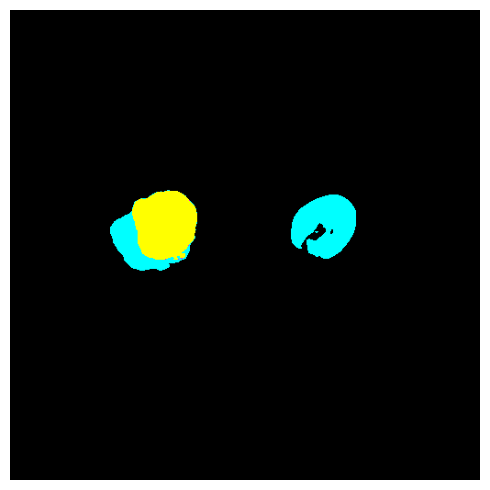

  - VOI size (resampled): (128, 128, 133)
  - VOI spacing (resampled): (1.0, 1.0, 1.0)

  TUMOR OF INTEREST (TOI) METRICS:
  - Tumor present: YES
  - Tumor voxels: 216,575
  - Tumor volume: 216575.00 mm³ (216.57 cm³)
  - Tumor percentage: 9.94%
  - Tumor bbox shape (voxels): W=77, H=79, D=83
  - Tumor bbox shape (mm): W=77.00, H=79.00, D=83.00
  - Mean HU: 102.11
  - Std HU: 36.84
  - Min HU: -72.00
  - Max HU: 238.00


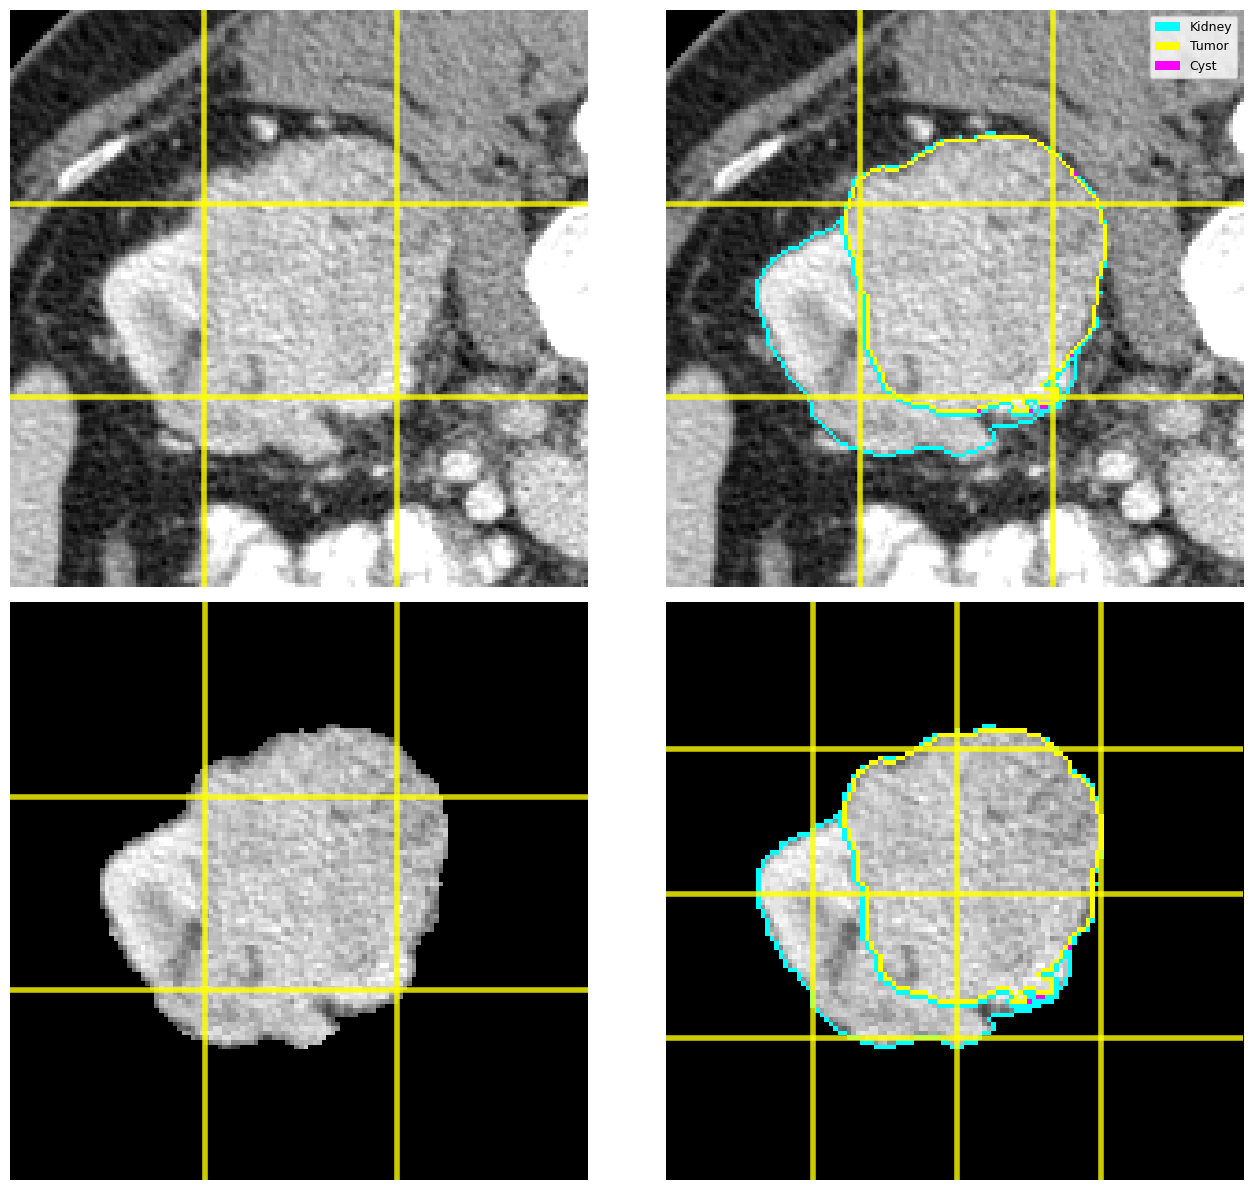


PROCESSING LEFT KIDNEY
  - VOI size (original): (156, 156, 128)
  - VOI spacing (original): (0.814453125, 0.814453125, 1.0)


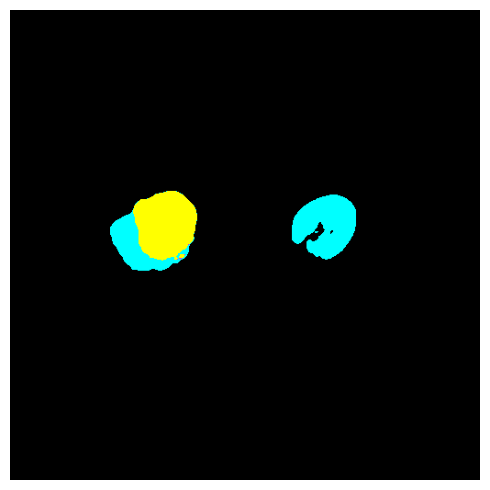

  - VOI size (resampled): (128, 128, 128)
  - VOI spacing (resampled): (1.0, 1.0, 1.0)

  TUMOR OF INTEREST (TOI) METRICS:
  - Tumor present: YES
  - Tumor voxels: 923
  - Tumor volume: 923.00 mm³ (0.92 cm³)
  - Tumor percentage: 0.04%
  - Tumor bbox shape (voxels): W=12, H=13, D=12
  - Tumor bbox shape (mm): W=12.00, H=13.00, D=12.00
  - Mean HU: 99.25
  - Std HU: 48.18
  - Min HU: -40.00
  - Max HU: 211.00


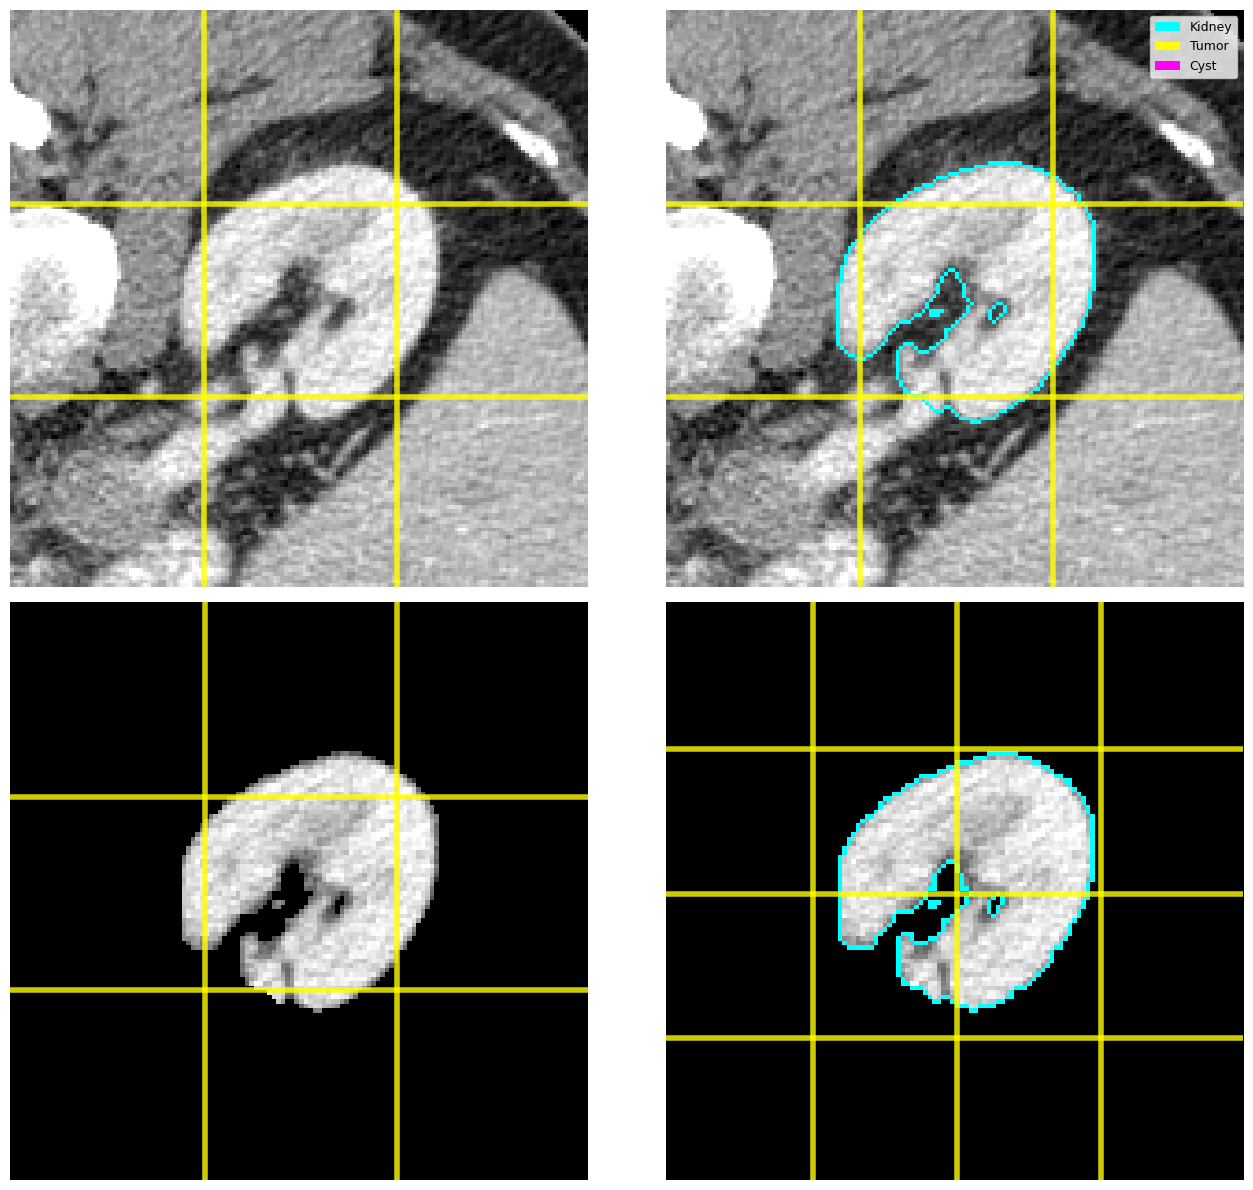


FINAL RESULTS


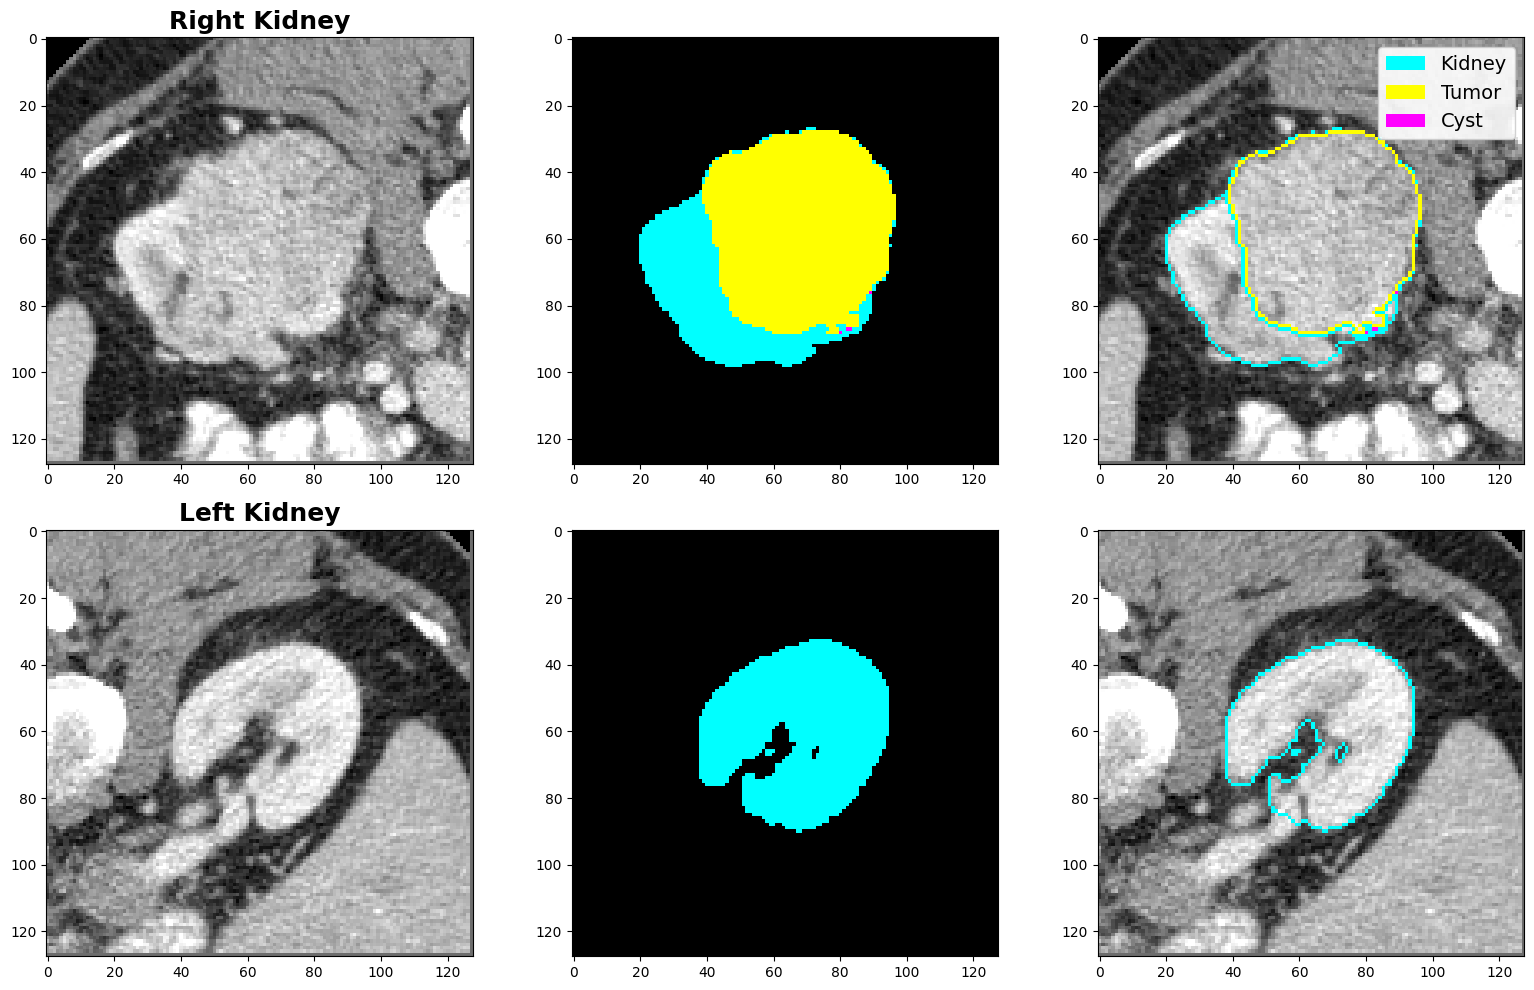

PIPELINE COMPLETED


In [3]:
import os
import random
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# CONFIGURATION
# ============================================================================
CONFIG = {
    'IMAGE_FOLDER': "../ukb2025_nii/",
    'MASK_FOLDER': "../ukb2025_seg/",
    'EXPANSION_MM': 0,
    'TARGET_SPACING': [1.0, 1.0, 1.0],
    'MIN_VOI_SIZE': [127, 127, 128],  # Minimum VOI size in voxels (12cm×12cm×14cm at 1mm spacing)
    'LABELS': {1: 'kidney', 2: 'tumor', 3: 'cyst'},
    'BBOX_LABELS': [1, 2],  # Compute bbox only on kidney (1) and tumor (2), exclude cyst (3)
    'USE_RAS_ORIENTATION': True  # Convert to RAS+ canonical orientation
}

# ============================================================================
# PREPROCESSING PIPELINE
# ============================================================================

class KidneyROIPreprocessingPipeline:
    """
    Pipeline for kidney ROI extraction and preprocessing.
    
    Steps:
    1. Load medical images (CT scan + segmentation mask)
    2. Convert to RAS+ canonical orientation (Right-Anterior-Superior) at ORIGINAL spacing
    3. Separate left and right kidneys using connected components
    4. Extract VOI (Volume of Interest) for each kidney at ORIGINAL spacing
    5. Resample VOI to target spacing (applied to smaller cropped volumes)
    6. Compute Tumor of Interest (TOI) metrics
    7. Visualize final results
    
    Benefits of this order:
    - Preserves original image quality during separation
    - Resampling applied only to smaller VOI volumes
    - Reduces interpolation artifacts
    """
    
    def __init__(self, config):
        self.config = config
        
    # ========================================================================
    # STEP 1: Load Data
    # ========================================================================
    def load_data(self, image_folder, mask_folder, case_name=None):
        """Load CT image and segmentation mask."""
        if case_name is None:
            # Select random case
            file_list = [f for f in os.listdir(image_folder) 
                        if f.endswith('_0000.nii.gz')]
            if not file_list:
                raise FileNotFoundError(f"No .nii.gz files in {image_folder}")
            case_name = random.choice(file_list).replace('_0000.nii.gz', '')
        
        image_path = os.path.join(image_folder, case_name + '_0000.nii.gz')
        mask_path = os.path.join(mask_folder, case_name + '.nii.gz')
        
        return sitk.ReadImage(image_path), sitk.ReadImage(mask_path), case_name
    
    # ========================================================================
    # STEP 2: Convert to RAS+ Orientation (at ORIGINAL spacing)
    # ========================================================================
    def convert_to_ras(self, image, mask):
        """
        Convert images to RAS+ canonical orientation at ORIGINAL spacing.
        RAS+ = Right-Anterior-Superior coordinate system (clinical standard)
        
        Benefits:
        - Consistent anatomical orientation across all images
        - Clinical standard for visualization and analysis
        - Simplifies left/right kidney identification
        - Ensures reproducibility across different scanner orientations
        - Applied BEFORE resampling to preserve original image quality
        """
        if not self.config.get('USE_RAS_ORIENTATION', True):
            return image, mask

        # Convert to RAS+ using DICOMOrient filter
        image_ras = sitk.DICOMOrient(image, 'RAS')
        mask_ras = sitk.DICOMOrient(mask, 'RAS')

        return image_ras, mask_ras
    
    # ========================================================================
    # STEP 3: Separate Kidneys and Calculate Bounding Boxes
    # ========================================================================
    def separate_kidneys(self, mask):
        """
        Separate left and right kidneys using a unified temporary mask.
        Operates on ORIGINAL spacing for better accuracy.
        
        Process:
        1. Create unified binary mask from BBOX_LABELS only (kidney + tumor, exclude cyst)
        2. Apply connected components to identify kidney components
        3. Handle 1 or 2 kidneys gracefully
        4. Use unified mask to calculate bbox for each kidney
        
        Note: In RAS+ orientation, smaller x = LEFT, larger x = RIGHT
        """

        mask_array = sitk.GetArrayFromImage(mask)
        
        # Create unified temporary mask from bbox_labels only (kidney=1, tumor=2, exclude cyst=3)
        bbox_labels = self.config.get('BBOX_LABELS', [1, 2])
        unified_mask = np.isin(mask_array, bbox_labels).astype(np.uint8)
        
        # Apply connected components on unified mask
        kidney_sitk = sitk.GetImageFromArray(unified_mask)
        kidney_sitk.CopyInformation(mask)
        labeled_components = sitk.ConnectedComponent(kidney_sitk)
        labeled_array = sitk.GetArrayFromImage(labeled_components)
        
        # Find up to 2 largest components
        stats = sitk.LabelShapeStatisticsImageFilter()
        stats.Execute(labeled_components)
        
        components = sorted(
            [(lbl, stats.GetNumberOfPixels(lbl), stats.GetCentroid(lbl)) 
             for lbl in stats.GetLabels()],
            key=lambda x: x[1], reverse=True
        )[:2]  # Take up to 2 largest
        
        if len(components) == 0:
            raise ValueError("No kidney components found in mask")
        
        # Determine left/right based on number of components
        bboxes = {}
        
        if len(components) == 1:
            # Only one kidney - determine if it's left or right by x-coordinate
            label, num_pixels, centroid = components[0]
            
            # Get image center x-coordinate
            image_center_x = (mask.GetSize()[0] * mask.GetSpacing()[0]) / 2
            
            # Determine side: if centroid is left of center, it's left kidney
            side = 'left' if centroid[0] < image_center_x else 'right'
            
            # Calculate bbox for this kidney
            kidney_mask = (labeled_array == label) & (unified_mask == 1)
            temp_sitk = sitk.GetImageFromArray(kidney_mask.astype(np.uint8))
            temp_sitk.CopyInformation(mask)
            
            bbox_stats = sitk.LabelShapeStatisticsImageFilter()
            bbox_stats.Execute(temp_sitk)
            
            if bbox_stats.GetLabels():
                bbox = bbox_stats.GetBoundingBox(1)
                bboxes[side] = {
                    'bbox': bbox,
                    'center_slice': bbox[2] + bbox[5] // 2
                }
        else:
            # Two kidneys - sort by x-coordinate: smaller x = left, larger x = right
            left_comp, right_comp = sorted(components, key=lambda x: x[2][0])

            # Calculate bounding boxes for both kidneys
            for side, (label, _, _) in [('left', left_comp), ('right', right_comp)]:
                kidney_mask = (labeled_array == label) & (unified_mask == 1)
                
                temp_sitk = sitk.GetImageFromArray(kidney_mask.astype(np.uint8))
                temp_sitk.CopyInformation(mask)
                
                bbox_stats = sitk.LabelShapeStatisticsImageFilter()
                bbox_stats.Execute(temp_sitk)
                
                if bbox_stats.GetLabels():
                    bbox = bbox_stats.GetBoundingBox(1)
                    bboxes[side] = {
                        'bbox': bbox,
                        'center_slice': bbox[2] + bbox[5] // 2
                    }

        return bboxes
    
    # ========================================================================
    # STEP 4: Extract and Crop VOI (at ORIGINAL spacing)
    # ========================================================================
    def extract_voi(self, image, mask, bbox_info):
        """
        Extract VOI using pre-calculated bbox with expansion margin.
        Operates at ORIGINAL spacing to preserve image quality.
        Ensures minimum VOI size of MIN_VOI_SIZE (default: 128×128×140 voxels at target spacing).
        """
        bbox = bbox_info['bbox']
        spacing = image.GetSpacing()
        target_spacing = np.array(self.config['TARGET_SPACING'])
        min_voi_size = np.array(self.config.get('MIN_VOI_SIZE', [128, 128, 140]))
        
        # Calculate minimum size in original spacing
        # min_size_original = min_voi_size * (target_spacing / original_spacing)
        min_size_original = np.ceil(min_voi_size * (target_spacing / np.array(spacing))).astype(int)
        
        # Calculate expansion in voxels
        expansion = [int(self.config['EXPANSION_MM'] / s) for s in spacing]
        
        # Initial bbox with expansion
        start = [max(0, bbox[i] - expansion[i]) for i in range(3)]
        end = [min(image.GetSize()[i], bbox[i] + bbox[i+3] + expansion[i]) for i in range(3)]
        size = [end[i] - start[i] for i in range(3)]
        
        # Ensure minimum size: expand bbox symmetrically if needed
        for i in range(3):
            if size[i] < min_size_original[i]:
                deficit = int(min_size_original[i] - size[i])
                # Expand both sides equally
                expand_start = deficit // 2
                expand_end = deficit - expand_start
                
                new_start = max(0, start[i] - expand_start)
                new_end = min(image.GetSize()[i], end[i] + expand_end)
                
                # If we hit image boundary, expand the other side more
                actual_deficit = int(min_size_original[i]) - (new_end - new_start)
                if actual_deficit > 0:
                    if new_start == 0:
                        new_end = min(image.GetSize()[i], new_end + actual_deficit)
                    elif new_end == image.GetSize()[i]:
                        new_start = max(0, new_start - actual_deficit)
                
                start[i] = new_start
                end[i] = new_end
                size[i] = end[i] - start[i]
        
        # Convert to Python integers (required by SimpleITK)
        start = [int(s) for s in start]
        size = [int(s) for s in size]
        
        # Crop and return
        return (
            sitk.RegionOfInterest(image, size=size, index=start),
            sitk.RegionOfInterest(mask, size=size, index=start),
            bbox_info['center_slice']
        )
    
    # ========================================================================
    # STEP 5: Resample VOI to Target Spacing with Anti-Aliasing
    # ========================================================================
    def resample_voi(self, image, mask):
        """
        Resample VOI to target spacing with anti-aliasing on downsampled axes.
        Applied AFTER VOI extraction to preserve original quality and reduce artifacts.
        
        Anti-aliasing strategy:
        - Apply Gaussian smoothing only on axes where downsampling occurs
        - Sigma determined by zoom factor (native_spacing / target_spacing)
        - Convert σ from output to input units: σ_in = σ_out / zoom
        
        Benefits of resampling after VOI extraction:
        - Smaller volume to process (faster)
        - Better preservation of original image quality
        - Fewer interpolation artifacts
        """
        
        target_spacing = np.array(self.config['TARGET_SPACING'])
        original_size = np.array(image.GetSize())
        original_spacing = np.array(image.GetSpacing())
        
        # Calculate zoom factors per axis
        zoom = original_spacing / target_spacing
        
        # # Determine sigma for anti-aliasing per axis
        # sigma_in_physical = []
        # for i, z in enumerate(zoom):
        #     sigma_out = 0.2  # Conservative smoothing
        #     # Convert to input units (physical spacing)
        #     sigma_in_physical.append(sigma_out * target_spacing[i] if sigma_out > 0 else 0.001)

        # # Apply Gaussian smoothing to image if any axis needs AA
        # if any(s > 0 for s in sigma_in_physical):
        #     image = sitk.SmoothingRecursiveGaussian(image, sigma_in_physical)

        # Calculate new size
        new_size = np.ceil(original_size * (original_spacing / target_spacing)).astype(np.uint32)
        
        # Resample image (BSpline interpolation for better quality)
        resampled_image = sitk.Resample(
            image, new_size.tolist(), sitk.Transform(),
            sitk.sitkBSpline, image.GetOrigin(),
            target_spacing.tolist(), image.GetDirection(), 0.0
        )
        
        # Resample mask (nearest neighbor to preserve labels, no AA)
        resampled_mask = sitk.Resample(
            mask, new_size.tolist(), sitk.Transform(),
            sitk.sitkNearestNeighbor, mask.GetOrigin(),
            target_spacing.tolist(), mask.GetDirection(), 0
        )

        return resampled_image, resampled_mask
    
    # ========================================================================
    # STEP 5.5: Compute Tumor of Interest (TOI) Metrics
    # ========================================================================
    def compute_toi_metrics(self, image, mask):
        """
        Compute Tumor of Interest (TOI) metrics based on mask label 2 (tumor).
        
        Metrics computed:
        - Tumor volume (mm³ and cm³)
        - Number of tumor voxels
        - Tumor percentage relative to total VOI
        - Mean HU value in tumor region
        - Std HU value in tumor region
        - Min/Max HU values in tumor region
        - Tumor bounding box dimensions (width, height, depth in mm)
        """
        img_array = sitk.GetArrayFromImage(image)
        mask_array = sitk.GetArrayFromImage(mask)
        spacing = image.GetSpacing()
        
        # Extract tumor voxels (label = 2)
        tumor_mask = (mask_array == 2)
        tumor_voxels = np.sum(tumor_mask)
        
        # Check if tumor exists
        if tumor_voxels == 0:
            return {
                'has_tumor': False,
                'tumor_voxels': 0,
                'tumor_volume_mm3': 0.0,
                'tumor_volume_cm3': 0.0,
                'tumor_percentage': 0.0,
                'mean_hu': None,
                'std_hu': None,
                'min_hu': None,
                'max_hu': None,
                'bbox_shape_voxels': None,
                'bbox_shape_mm': None
            }
        
        # Compute volume (voxel_volume = spacing[0] * spacing[1] * spacing[2])
        voxel_volume_mm3 = spacing[0] * spacing[1] * spacing[2]
        tumor_volume_mm3 = tumor_voxels * voxel_volume_mm3
        tumor_volume_cm3 = tumor_volume_mm3 / 1000.0
        
        # Compute tumor percentage
        total_voxels = mask_array.size
        tumor_percentage = (tumor_voxels / total_voxels) * 100.0
        
        # Compute HU statistics in tumor region
        tumor_hu_values = img_array[tumor_mask]
        mean_hu = float(np.mean(tumor_hu_values))
        std_hu = float(np.std(tumor_hu_values))
        min_hu = float(np.min(tumor_hu_values))
        max_hu = float(np.max(tumor_hu_values))
        
        # Compute tumor bounding box
        tumor_sitk = sitk.GetImageFromArray(tumor_mask.astype(np.uint8))
        tumor_sitk.CopyInformation(mask)
        
        bbox_filter = sitk.LabelShapeStatisticsImageFilter()
        bbox_filter.Execute(tumor_sitk)
        
        if bbox_filter.GetLabels():
            # Get bounding box (x_start, y_start, z_start, x_size, y_size, z_size)
            bbox = bbox_filter.GetBoundingBox(1)
            bbox_shape_voxels = (bbox[3], bbox[4], bbox[5])  # width, height, depth in voxels
            bbox_shape_mm = (
                bbox[3] * spacing[0],  # width in mm
                bbox[4] * spacing[1],  # height in mm
                bbox[5] * spacing[2]   # depth in mm
            )
        else:
            bbox_shape_voxels = None
            bbox_shape_mm = None
        
        return {
            'has_tumor': True,
            'tumor_voxels': int(tumor_voxels),
            'tumor_volume_mm3': float(tumor_volume_mm3),
            'tumor_volume_cm3': float(tumor_volume_cm3),
            'tumor_percentage': float(tumor_percentage),
            'mean_hu': mean_hu,
            'std_hu': std_hu,
            'min_hu': min_hu,
            'max_hu': max_hu,
            'bbox_shape_voxels': bbox_shape_voxels,
            'bbox_shape_mm': bbox_shape_mm
        }
    
    # ========================================================================
    # STEP 5.6: Visualize Center Slice on Full Original CT
    # ========================================================================
    def visualize_full_ct(self, image, mask, center_slice_idx, side):
        """Visualize center slice of kidney on full original CT with colored boundaries for each label."""
        from scipy import ndimage
        
        img_array = sitk.GetArrayFromImage(image)
        mask_array = sitk.GetArrayFromImage(mask)
        
        # Validate slice index
        center_slice_idx = min(center_slice_idx, img_array.shape[0] - 1)
        
        # Define high contrast colors (RGB): kidney=cyan, tumor=yellow, cyst=magenta
        label_colors = {
            1: [0, 1, 1],      # Cyan for kidney
            2: [1, 1, 0],      # Yellow for tumor
            3: [1, 0, 1]       # Magenta for cyst
        }
        
        fig, axes = plt.subplots(1, 1, figsize=(12, 5))

        # CT + multi-label boundary overlay
        # Create RGB version of CT for better blending
        ct_slice = img_array[center_slice_idx]
        ct_normalized = np.clip((ct_slice - (-150)) / (200 - (-150)), 0, 1)
        ct_rgb = np.stack([ct_normalized] * 3, axis=-1)
        ct_array_zeros = np.zeros_like(ct_rgb)
        # # Add colored boundaries with high intensity
        # for label, color in label_colors.items():
        #     mask_slice = mask_array[center_slice_idx] == label
        #     if mask_slice.any():
        #         boundary = mask_slice ^ ndimage.binary_erosion(mask_slice)
        #         ct_rgb[boundary] = color
        # color map mask_array
        for label, color in label_colors.items():
            mask_slice = mask_array[center_slice_idx] == label
            if mask_slice.any():
                ct_array_zeros[mask_slice] = color
        axes.imshow(ct_array_zeros)
        axes.axis('off')
        # axes.set_title(f'{side} Kidney - Center Slice on Full Original CT (RAS+ orientation)', fontsize=12)

        # Add legend to top-right
        # from matplotlib.patches import Patch
        # legend_elements = [
        #     Patch(facecolor=[0, 1, 1], label='Kidney'),
        #     Patch(facecolor=[1, 1, 0], label='Tumor'),
        #     Patch(facecolor=[1, 0, 1], label='Cyst')
        # ]
        # axes.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.8)

        plt.tight_layout()
        plt.show()
    
    # ========================================================================
    # STEP 5.7: Visualize VOI Comparison (Original vs Resampled)
    # ========================================================================
    def visualize_voi_comparison(self, original_img, original_mask, resampled_img, resampled_mask, side):
        """Compare original VOI vs resampled VOI to assess quality."""
        from scipy import ndimage
        
        # Convert to numpy
        orig_img_array = sitk.GetArrayFromImage(original_img)
        orig_mask_array = sitk.GetArrayFromImage(original_mask)
        resamp_img_array = sitk.GetArrayFromImage(resampled_img)
        resamp_mask_array = sitk.GetArrayFromImage(resampled_mask)
        
        # Get middle slices
        orig_mid = orig_img_array.shape[0] // 2
        resamp_mid = resamp_img_array.shape[0] // 2
        
        # Define high contrast colors (RGB): kidney=cyan, tumor=yellow, cyst=magenta
        label_colors = {
            1: [0, 1, 1],      # Cyan for kidney
            2: [1, 1, 0],      # Yellow for tumor
            3: [1, 0, 1]       # Magenta for cyst
        }
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        
        # Original VOI - CT only
        axes[0, 0].imshow(orig_img_array[orig_mid], cmap='gray', vmin=-150, vmax=200)
        # Draw 4x4 grid
        h0, w0 = orig_img_array[orig_mid].shape
        for row in range(1, 3):
            y = row * h0 / 3
            axes[0, 0].axhline(y=y, color='yellow', linewidth=4, alpha=0.8)
        for col in range(1, 3):
            x = col * w0 / 3
            axes[0, 0].axvline(x=x, color='yellow', linewidth=4, alpha=0.8)
        axes[0, 0].axis('off')
        
        # Original VOI - CT + boundaries
        ct_slice = orig_img_array[orig_mid]
        ct_normalized = np.clip((ct_slice - (-150)) / (200 - (-150)), 0, 1)
        ct_rgb = np.stack([ct_normalized] * 3, axis=-1)
        for label, color in label_colors.items():
            mask_slice = orig_mask_array[orig_mid] == label
            if mask_slice.any():
                boundary = mask_slice ^ ndimage.binary_erosion(mask_slice)
                ct_rgb[boundary] = color
        axes[0, 1].imshow(ct_rgb)
        # Draw 4x4 grid
        for row in range(1, 3):
            y = row * h0 / 3
            axes[0, 1].axhline(y=y, color='yellow', linewidth=4, alpha=0.8)
        for col in range(1, 3):
            x = col * w0 / 3
            axes[0, 1].axvline(x=x, color='yellow', linewidth=4, alpha=0.8)
        axes[0, 1].axis('off')
        
        # Resampled VOI - CT only
        axes[1, 0].imshow(resamp_img_array[resamp_mid], cmap='gray', vmin=-150, vmax=200)
        # Draw 4x4 grid
        h1, w1 = resamp_img_array[resamp_mid].shape
        for row in range(1, 3):
            y = row * h1 / 3
            axes[1, 0].axhline(y=y, color='yellow', linewidth=4, alpha=0.8)
        for col in range(1, 3):
            x = col * w1 / 3
            axes[1, 0].axvline(x=x, color='yellow', linewidth=4, alpha=0.8)
        axes[1, 0].axis('off')
        
        # Resampled VOI - CT + boundaries
        ct_slice = resamp_img_array[resamp_mid]
        ct_normalized = np.clip((ct_slice - (-150)) / (200 - (-150)), 0, 1)
        ct_rgb = np.stack([ct_normalized] * 3, axis=-1)
        for label, color in label_colors.items():
            mask_slice = resamp_mask_array[resamp_mid] == label
            if mask_slice.any():
                boundary = mask_slice ^ ndimage.binary_erosion(mask_slice)
                ct_rgb[boundary] = color
        axes[1, 1].imshow(ct_rgb)
        # Draw 4x4 grid
        for row in range(1, 4):
            y = row * h1 / 4
            axes[1, 1].axhline(y=y, color='yellow', linewidth=4, alpha=0.8)
        for col in range(1, 4):
            x = col * w1 / 4
            axes[1, 1].axvline(x=x, color='yellow', linewidth=4, alpha=0.8)
        axes[1, 1].axis('off')
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=[0, 1, 1], label='Kidney'),
            Patch(facecolor=[1, 1, 0], label='Tumor'),
            Patch(facecolor=[1, 0, 1], label='Cyst')
        ]
        axes[0, 1].legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.8)
        
        plt.tight_layout()
        plt.show()
    # ========================================================================
    # STEP 5.8: Apply Mask to Resampled VOI to create SEGMENTED_VOI
    # ========================================================================
    def apply_mask_to_voi(self, resampled_img, resampled_mask):
        """
        Apply mask to resampled VOI:
        - Keep voxel values where mask > 0
        - Set background voxels to HU = -1000
        """
        img_array = sitk.GetArrayFromImage(resampled_img)
        mask_array = sitk.GetArrayFromImage(resampled_mask)
        
        # Initialize output array with HU = -1000
        segmented_array = np.full_like(img_array, fill_value=-1000)
        
        # Copy voxel values where mask > 0
        segmented_array[mask_array > 0] = img_array[mask_array > 0]
        
        # Convert back to SimpleITK image
        segmented_img = sitk.GetImageFromArray(segmented_array)
        segmented_img.CopyInformation(resampled_img)
        
        return segmented_img
    # ========================================================================
    # STEP 6: Visualize Results
    # ========================================================================
    def visualize(self, right_img, right_mask, left_img, left_mask):
        """Visualize middle slices of both kidneys with colored boundaries for each label."""
        from scipy import ndimage
        from matplotlib.colors import ListedColormap
        
        # Define high contrast colors (RGB): kidney=cyan, tumor=yellow, cyst=magenta
        label_colors = {
            1: [0, 1, 1],      # Cyan for kidney
            2: [1, 1, 0],      # Yellow for tumor
            3: [1, 0, 1]       # Magenta for cyst
        }
        
        # Create custom colormap for mask visualization
        # Background (0) = black, then same colors as boundaries
        cmap_colors = [[0, 0, 0]] + [label_colors.get(i, [1, 1, 1]) for i in range(1, 4)]
        custom_cmap = ListedColormap(cmap_colors)
        
        # Convert to numpy and get middle slices
        images = [
            (sitk.GetArrayFromImage(right_img), sitk.GetArrayFromImage(right_mask), 'Right'),
            (sitk.GetArrayFromImage(left_img), sitk.GetArrayFromImage(left_mask), 'Left')
        ]
        
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        
        for i, (img_np, mask_np, side) in enumerate(images):
            mid_slice = img_np.shape[0] // 2
            h, w = img_np[mid_slice].shape
            
            # Column 0: CT image only
            axes[i, 0].imshow(img_np[mid_slice], cmap='gray', vmin=-150, vmax=200)
            axes[i, 0].set_title(f'{side} Kidney', fontsize=18, weight='bold')
            
            # Column 1: Mask only with same colormap
            axes[i, 1].imshow(mask_np[mid_slice], cmap=custom_cmap, vmin=0, vmax=3, interpolation='nearest')
            
            # Column 2: CT + multi-label boundary overlay
            # Create RGB version of CT for better blending
            ct_slice = img_np[mid_slice]
            ct_normalized = np.clip((ct_slice - (-150)) / (200 - (-150)), 0, 1)
            ct_rgb = np.stack([ct_normalized] * 3, axis=-1)
            # Add colored boundaries with high intensity
            for label, color in label_colors.items():
                mask_slice = mask_np[mid_slice] == label
                if mask_slice.any():
                    boundary = mask_slice ^ ndimage.binary_erosion(mask_slice)
                    ct_rgb[boundary] = color
            axes[i, 2].imshow(ct_rgb)
            # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=[0, 1, 1], label='Kidney'),
            Patch(facecolor=[1, 1, 0], label='Tumor'),
            Patch(facecolor=[1, 0, 1], label='Cyst')
        ]
        axes[0, 2].legend(handles=legend_elements, loc='upper right', fontsize=14, framealpha=0.9)
        
        plt.tight_layout()
        plt.show()
    
    # ========================================================================
    # Full Pipeline Execution
    # ========================================================================
    def run(self, case_name=None):
        """Execute the complete preprocessing pipeline."""
        print("="*70)
        print("KIDNEY ROI PREPROCESSING PIPELINE")
        print("="*70)
        
        # Step 1: Load data
        image, mask, case_name = self.load_data(
            self.config['IMAGE_FOLDER'], self.config['MASK_FOLDER'], case_name
        )
        print(f"Case: {case_name}")
        print(f"Original spacing: {image.GetSpacing()}")
        print(f"Original size: {image.GetSize()}")
        
        # Step 2: Convert to RAS+ (at original spacing)
        image, mask = self.convert_to_ras(image, mask)
        
        # Step 3: Separate kidneys and get bboxes
        bboxes = self.separate_kidneys(mask)
        
        # Steps 4-5: Extract VOI and resample for available kidneys
        results = {'case_name': case_name}
        for side in ['right', 'left']:
            if side not in bboxes:
                print(f"\n{side.capitalize()} kidney not found, skipping...")
                continue
                
            print(f"\n{'='*70}")
            print(f"PROCESSING {side.upper()} KIDNEY")
            print('='*70)
            
            # Step 4: Extract VOI at original spacing
            original_voi_img, original_voi_mask, center = self.extract_voi(image, mask, bboxes[side])
            print(f"  - VOI size (original): {original_voi_img.GetSize()}")
            print(f"  - VOI spacing (original): {original_voi_img.GetSpacing()}")
            
            # Visualize center slice on full original CT
            self.visualize_full_ct(image, mask, center, side.capitalize())
            
            # Step 5: Resample VOI to target spacing
            resampled_voi_img, resampled_voi_mask = self.resample_voi(original_voi_img, original_voi_mask)
            print(f"  - VOI size (resampled): {resampled_voi_img.GetSize()}")
            print(f"  - VOI spacing (resampled): {resampled_voi_img.GetSpacing()}")
            
            
            
            # Compute TOI metrics
            toi_metrics = self.compute_toi_metrics(resampled_voi_img, resampled_voi_mask)
            print(f"\n  TUMOR OF INTEREST (TOI) METRICS:")
            print(f"  {'='*66}")
            if toi_metrics['has_tumor']:
                print(f"  - Tumor present: YES")
                print(f"  - Tumor voxels: {toi_metrics['tumor_voxels']:,}")
                print(f"  - Tumor volume: {toi_metrics['tumor_volume_mm3']:.2f} mm³ ({toi_metrics['tumor_volume_cm3']:.2f} cm³)")
                print(f"  - Tumor percentage: {toi_metrics['tumor_percentage']:.2f}%")
                if toi_metrics['bbox_shape_mm']:
                    print(f"  - Tumor bbox shape (voxels): W={toi_metrics['bbox_shape_voxels'][0]}, H={toi_metrics['bbox_shape_voxels'][1]}, D={toi_metrics['bbox_shape_voxels'][2]}")
                    print(f"  - Tumor bbox shape (mm): W={toi_metrics['bbox_shape_mm'][0]:.2f}, H={toi_metrics['bbox_shape_mm'][1]:.2f}, D={toi_metrics['bbox_shape_mm'][2]:.2f}")
                print(f"  - Mean HU: {toi_metrics['mean_hu']:.2f}")
                print(f"  - Std HU: {toi_metrics['std_hu']:.2f}")
                print(f"  - Min HU: {toi_metrics['min_hu']:.2f}")
                print(f"  - Max HU: {toi_metrics['max_hu']:.2f}")
            else:
                print(f"  - Tumor present: NO")
            print(f"  {'='*66}")
            segmented_voi_img = self.apply_mask_to_voi(resampled_voi_img, resampled_voi_mask)
            # segmented_voi_img = resampled_voi_img
            # Visualize comparison: Original vs Resampled VOI
            self.visualize_voi_comparison(original_voi_img, original_voi_mask, 
                                         segmented_voi_img, resampled_voi_mask, 
                                         side.capitalize())
            
            results[f'{side}_segmented_voi'] = segmented_voi_img
            results[f'{side}_image'] = resampled_voi_img
            results[f'{side}_mask'] = resampled_voi_mask
            results[f'{side}_center_slice'] = center
            results[f'{side}_toi_metrics'] = toi_metrics
        
        # Step 6: Final visualization (only if both kidneys are present)
        if 'right_image' in results and 'left_image' in results:
            print(f"\n{'='*70}")
            print("FINAL RESULTS")
            print('='*70)
            self.visualize(results['right_image'], results['right_mask'],
                          results['left_image'], results['left_mask'])
        
        print("="*70)
        print("PIPELINE COMPLETED")
        print("="*70)
        
        return results


pipeline = KidneyROIPreprocessingPipeline(CONFIG)
results = pipeline.run(case_name='Anonym_9K2ZS6_scan2_case_00007')


In [ ]:
from skimage import measure

def matplotlib_surface(mask, color=(0.2, 0.4, 1.0), alpha=0.5, elev=20, azim=30, title=None):
        verts, faces, _, _ = measure.marching_cubes(mask, level=0.5)
        fig = plt.figure(figsize=(8, 8), dpi=100)
        ax = fig.add_subplot(111, projection='3d')
        ax.set_facecolor((0.525, 0.541, 0.788))
        fig.patch.set_facecolor((0.525, 0.541, 0.788))
        mesh = ax.plot_trisurf( # type: ignore
            verts[:, 0], verts[:, 1], faces, verts[:, 2],
            color=color, lw=0.2, alpha=alpha, edgecolor='none'
        )
        ax.set_axis_off()
        ax.view_init(elev=elev, azim=azim, roll=30) # type: ignore
        ax.set_box_aspect([1,1,1]) # type: ignore
        ax.set_xlim(verts[:, 0].min(), verts[:, 0].max())
        ax.set_ylim(verts[:, 1].min(), verts[:, 1].max())
        ax.set_zlim(verts[:, 2].min(), verts[:, 2].max()) # type: ignore

        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8) # type: ignore
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plt.close(fig)
        return img

right_seg_voi = results['right_mask']
right_seg_array = sitk.GetArrayFromImage(right_seg_voi)
# transpose to (Z, Y, X)
# right_seg_array = np.transpose(right_seg_array, (1, 2, 0))
# Separate mask=1 and mask=2 into 2 different binary masks
right_mask_1 = (right_seg_array == 1).astype(np.uint8)
right_mask_2 = (right_seg_array == 2).astype(np.uint8)

# Plot 3D surfaces in a single plot different colors based on mask label
fig = plt.figure(figsize=(10, 10), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# Plot kidney surface (mask=1) in cyan
verts1, faces1, _, _ = measure.marching_cubes(right_mask_1, level=0.5)
ax.plot_trisurf( # type: ignore
    verts1[:, 0], verts1[:, 1], faces1, verts1[:, 2],
    color=(0, 1, 1), lw=0.2, alpha=0.5, edgecolor='none'
)
# Plot tumor surface (mask=2) in yellow
verts2, faces2, _, _ = measure.marching_cubes(right_mask_2, level=0.5)
ax.plot_trisurf( # type: ignore
    verts2[:, 0], verts2[:, 1], faces2, verts2[:, 2],
    color=(1, 1, 0), lw=0.2, alpha=0.7, edgecolor='none'
)
ax.set_axis_off()
fig.patch.set_facecolor((0.525, 0.541, 0.788))
ax.set_facecolor((0.525, 0.541, 0.788))
ax.view_init(elev=0, azim=90, roll=-90) # type: ignore
ax.set_box_aspect([1,1,1]) # type: ignore
ax.set_xlim(0, right_seg_array.shape[2])
ax.set_ylim(0, right_seg_array.shape[1])
ax.set_zlim(0, right_seg_array.shape[0]) # type: ignore 

In [ ]:

from pathlib import Path
import json
from tqdm import tqdm

# Configuration for batch processing
BATCH_CONFIG = {
    'IMAGE_FOLDER': "/home/alonso/Documents/radiopatho_backup/data/dataset/ukb2025_nii/",
    'MASK_FOLDER': "/home/alonso/Documents/radiopatho_backup/data/dataset/ukb2025_seg/",
    'OUTPUT_DIR': "../ukb2025_1_voi/",
    'EXPANSION_MM': 0,
    'TARGET_SPACING': [1.00, 1.00, 1.00],
    'MIN_VOI_SIZE': [127, 127, 127],  # Minimum VOI size in voxels (12cm×12cm×14cm at 1mm spacing)
    'LABELS': {1: 'kidney', 2: 'tumor', 3: 'cyst'},
    'BBOX_LABELS': [1, 2],  # Compute bbox only on kidney (1) and tumor (2), exclude cyst (3)
    'USE_RAS_ORIENTATION': True  # Convert to RAS+ canonical orientation
}

# Create output directories
output_base = Path(BATCH_CONFIG['OUTPUT_DIR'])
output_base.mkdir(exist_ok=True, parents=True)
output_masks = Path(str(output_base) + "_masks")
output_masks.mkdir(exist_ok=True, parents=True)

# Initialize pipeline with BATCH_CONFIG
batch_pipeline = KidneyROIPreprocessingPipeline(BATCH_CONFIG)

# Check if 'pairs' variable exists, if not create it

print("Creating image-mask pairs from batch config...")
image_dir = Path(BATCH_CONFIG['IMAGE_FOLDER'])
mask_dir = Path(BATCH_CONFIG['MASK_FOLDER'])

# Find all CT images ending with _0000.nii.gz (recursively in all subfolders)
image_files = sorted(list(image_dir.rglob("*_0000.nii.gz")))
print(f"{len(image_files)} CT images found")

# Create pairs by matching case names
pairs = []
for img_path in image_files:
    # Extract case name by removing _0000.nii.gz suffix
    case_name = img_path.stem.replace("_0000.nii", "")
    print(case_name)
    # Look for corresponding mask file (recursively in mask_dir)
    mask_matches = list(mask_dir.rglob(f"{case_name}.nii.gz"))
    
    if mask_matches:
        mask_path = mask_matches[0]  # Take first match
        pairs.append({
            'case_name': case_name,
            'image_path': str(img_path),
            'mask_path': str(mask_path)
        })
    else:
        print(f"Warning: No mask found for {case_name}")

print(f"Found {len(pairs)} image-mask pairs")

# Process all pairs with complete pipeline steps
processing_report = {}
failed_cases = []

print(f"\n{'='*70}")
print("STARTING BATCH PROCESSING")
print(f"{'='*70}")
print(f"Total cases to process: {len(pairs)}")
print(f"Output directory: {output_base}")
print(f"Output masks directory: {output_masks}")
print(f"{'='*70}\n")

for idx, pair in enumerate(tqdm(pairs, desc="Processing cases")):
    case_name = pair['case_name']
    
    try:
        # STEP 1: Load data
        image = sitk.ReadImage(pair['image_path'])
        mask = sitk.ReadImage(pair['mask_path'])
        
        # STEP 2: Convert to RAS+ canonical orientation (at original spacing)
        image, mask = batch_pipeline.convert_to_ras(image, mask)
        
        # STEP 3: Separate kidneys and get bboxes
        bboxes = batch_pipeline.separate_kidneys(mask)
        
        if not bboxes:
            raise ValueError("No kidneys found in mask")
        
        # Initialize case results
        case_results = {
            'case_name': case_name,
            'original_spacing': image.GetSpacing(),
            'original_size': image.GetSize(),
            'kidneys': {}
        }
        kidney_processed = False
        
        # STEP 4-5: Extract VOI and resample for available kidneys
        for side in ['right', 'left']:
            if side not in bboxes:
                continue
            
            try:
                # STEP 4: Extract VOI at original spacing
                original_voi_img, original_voi_mask, center = batch_pipeline.extract_voi(
                    image, mask, bboxes[side]
                )
                
                # STEP 5: Resample VOI to target spacing
                resampled_voi_img, resampled_voi_mask = batch_pipeline.resample_voi(
                    original_voi_img, original_voi_mask
                )
                
                # STEP 5.5: Compute TOI (Tumor of Interest) metrics
                toi_metrics = batch_pipeline.compute_toi_metrics(
                    resampled_voi_img, resampled_voi_mask
                )
                segmented_voi = batch_pipeline.apply_mask_to_voi(resampled_voi_img, resampled_voi_mask)
                
                # Convert to numpy arrays
                img_array = sitk.GetArrayFromImage(segmented_voi)
                mask_array = sitk.GetArrayFromImage(resampled_voi_mask)
                
                # Create output subdirectories matching input structure
                relative_path = Path(pair['image_path']).parent.relative_to(
                    Path(BATCH_CONFIG['IMAGE_FOLDER'])
                )
                output_img_subdir = output_base / relative_path
                output_img_subdir.mkdir(exist_ok=True, parents=True)
                output_mask_subdir = output_masks / relative_path
                output_mask_subdir.mkdir(exist_ok=True, parents=True)
                
                # Generate filenames
                output_name = f"{case_name}_{side[0].upper()}"
                img_path = output_img_subdir / f"{output_name}.npy"
                mask_path = output_mask_subdir / f"{output_name}.npy"
                
                # Save files - mask saved with original labels (0, 1, 2, 3)
                np.save(img_path, img_array.astype(np.float32))
                np.save(mask_path, mask_array.astype(np.uint8))
                
                # Store metadata including TOI metrics
                case_results['kidneys'][side] = {
                    'voi_shape': img_array.shape,
                    'voi_spacing': resampled_voi_img.GetSpacing(),
                    'label_counts': {int(k): int(v) for k, v in zip(*np.unique(mask_array, return_counts=True))},
                    'toi_metrics': toi_metrics,
                    'saved_image': str(img_path),
                    'saved_mask': str(mask_path)
                }
                kidney_processed = True
                
            except Exception as e:
                case_results['kidneys'][side] = {'error': str(e)}
        
        if kidney_processed:
            processing_report[case_name] = case_results
        else:
            raise ValueError("Failed to process any available kidneys")
        
    except Exception as e:
        failed_cases.append({'case_name': case_name, 'error': str(e)})

# Save processing report
report_path = output_base / "processing_report.json"
with open(report_path, 'w') as f:
    json.dump({
        'total_cases': len(pairs),
        'successful': len(processing_report),
        'failed': len(failed_cases),
        'config': BATCH_CONFIG,
        'results': processing_report,
        'failed_cases': failed_cases
    }, f, indent=2)

print(f"\n{'='*70}")
print("BATCH PROCESSING SUMMARY")
print(f"{'='*70}")
print(f"Total cases: {len(pairs)}")
print(f"Successfully processed: {len(processing_report)}")
print(f"Failed: {len(failed_cases)}")
if failed_cases:
    print(f"\nFirst 5 failed cases:")
    for fc in failed_cases[:5]:
        print(f"  - {fc['case_name']}: {fc['error']}")
print(f"\nProcessing report saved to: {report_path}")
print(f"{'='*70}")


In [ ]:
from pathlib import Path
from tqdm import tqdm
import numpy as np

def compute_dataset_statistics(base_dir, exclude_folders=[''], ignore_value=-1000, clip_min=-200, clip_max=300):
    """
    Compute mean and std of entire dataset excluding specified folders and ignoring a specific value.
    Clips voxel values to [clip_min, clip_max] before calculation.
    """
    base_path = Path(base_dir)
    all_files = []
    for npy_file in base_path.rglob("*.npy"):
        if not any(excluded in npy_file.parts for excluded in exclude_folders):
            all_files.append(npy_file)
    print(f"Found {len(all_files)} files (excluding {exclude_folders})")

    # First pass: compute mean and collect percentiles
    print("\nComputing mean and percentiles...")
    running_sum = 0.0
    total_voxels = 0
    percentiles_data = []
    for file_path in tqdm(all_files, desc="Pass 1: Mean/Percentiles"):
        data = np.load(file_path)
        data = np.clip(data, clip_min, clip_max)
        running_sum += data.sum()
        total_voxels += data.size
        percentiles_data.append(data.ravel())
    mean = running_sum / total_voxels
    print(f"Mean: {mean:.4f}")

    # Compute percentiles (25th and 75th) on all data
    all_data = np.concatenate(percentiles_data)
    p25 = float(np.percentile(all_data, 25))
    p75 = float(np.percentile(all_data, 75))
    print(f"25th percentile: {p25:.4f}")
    print(f"75th percentile: {p75:.4f}")

    # Second pass: compute std
    print("\nComputing std...")
    running_sq_diff = 0.0
    for file_path in tqdm(all_files, desc="Pass 2: Std"):
        data = np.load(file_path)
        data = np.clip(data, clip_min, clip_max)
        sq_diff = (data - mean) ** 2
        running_sq_diff += sq_diff.sum()
    std = np.sqrt(running_sq_diff / total_voxels)
    print(f"Std: {std:.4f}")

    return {
        'mean': float(mean),
        'std': float(std),
        'total_files': len(all_files),
        'total_voxels': int(total_voxels),
        'excluded_folders': exclude_folders,
        'ignore_value': ignore_value,
        'clip_min': clip_min,
        'clip_max': clip_max
    }

# Compute statistics for the dataset
stats = compute_dataset_statistics(
    base_dir='/home/alonso/Documents/radiopatho_backup/data/dataset/tcga_kirc_v3_f',
    ignore_value=-1000,
    clip_min=-200,
    clip_max=300
)


In [ ]:
"""
Radiomics extraction (pickle-free):
- Derives feature columns from what PyRadiomics actually returns.
- Drops diagnostics_* keys.
- Converts values to scalars safely.
- Skips cases without REQUIRED_LABEL in the mask.
- Writes a single CSV with consistent columns across all cases.
"""

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
from radiomics import featureextractor
from tqdm import tqdm

# ------------------------------- Config ------------------------------- #
PARAMS_YAML = "/home/alonso/Documents/radiopatho_backup/radiomics_params.yaml"
IMAGE_ROOT  = Path("/home/alonso/Documents/ccRCC/data/tcga_kirc_voi_f_tumor/img/")
MASK_ROOT   = Path("/home/alonso/Documents/ccRCC/data/tcga_kirc_voi_f/msk/")
OUTPUT_CSV  = IMAGE_ROOT / "radiomics_features.csv"
FAILED_CSV  = IMAGE_ROOT / "failed_extractions.csv"
REQUIRED_LABEL = 2  # set to None to accept any non-zero mask
# --------------------------------------------------------------------- #

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 160)


def safe_float(x):
    """Convert scalars/arrays/lists to float if possible, else return np.nan."""
    try:
        if isinstance(x, (int, float, np.number)):
            return float(x)
        arr = np.asarray(x)
        if arr.size == 0:
            return np.nan
        return float(arr.reshape(-1)[0])
    except Exception:
        return np.nan


def clean_feature_dict(feat_dict):
    """Drop diagnostics_* keys and coerce values to floats."""
    out = {}
    for k, v in feat_dict.items():
        if k.startswith("diagnostics_"):
            continue
        val = safe_float(v)
        if np.isfinite(val):
            out[k] = val
    return out


def find_image_mask_pairs(image_root: Path, mask_root: Path, ext=".npy"):
    imgs = sorted(image_root.rglob(f"*{ext}"))
    pairs = []
    for img_path in imgs:
        rel = img_path.relative_to(image_root)  # keep subfolders
        mask_path = mask_root / rel
        if mask_path.exists():
            pairs.append({
                "case_name": img_path.stem,
                "class_label": img_path.parent.name,
                "image_path": img_path,
                "mask_path": mask_path
            })
        else:
            print(f"Warning: No mask found for {img_path.stem} at {mask_path}")
    return pairs


def main():
    # 1) Initialize extractor
    extractor = featureextractor.RadiomicsFeatureExtractor(PARAMS_YAML)
    print("\n=== PyRadiomics Extractor ===")
    print("Settings:", extractor.settings)
    print("Image types:", extractor.enabledImagetypes)
    print("Enabled features:", extractor.enabledFeatures)

    # 2) Pair images and masks
    pairs = find_image_mask_pairs(IMAGE_ROOT, MASK_ROOT, ext=".npy")
    print(f"\nFound {len(pairs)} image-mask pairs under {IMAGE_ROOT}")

    # 3) Extract
    records = []
    failed = []
    all_keys = set()

    for p in tqdm(pairs, desc="Extracting radiomics"):
        case_name = p["case_name"]
        class_label = p["class_label"]

        try:
            img = np.load(p["image_path"]).squeeze()
            msk = np.load(p["mask_path"]).squeeze().astype(np.uint8)

            # Label check
            if REQUIRED_LABEL is None:
                if not np.any(msk):
                    failed.append({"case_name": case_name, "reason": "mask_all_zero"})
                    continue
                label_for_exec = 1  # radiomics requires an integer label; binary mask assumed
                msk = (msk > 0).astype(np.uint8)
            else:
                if not np.any(msk == REQUIRED_LABEL):
                    failed.append({"case_name": case_name, "reason": f"label_{REQUIRED_LABEL}_absent"})
                    continue
                label_for_exec = REQUIRED_LABEL

            itk_img = sitk.GetImageFromArray(img)
            itk_msk = sitk.GetImageFromArray(msk)

            feats_raw = extractor.execute(itk_img, itk_msk, label=label_for_exec)
            feats = clean_feature_dict(feats_raw)
            if not feats:
                failed.append({"case_name": case_name, "reason": "no_features_returned"})
                continue

            all_keys.update(feats.keys())
            records.append({"case_name": case_name, "class": class_label, **feats})

        except Exception as e:
            failed.append({"case_name": case_name, "reason": str(e)})

    # 4) Save
    if not records:
        print("\nNo successful extractions. Nothing to save.")
        if failed:
            pd.DataFrame(failed).to_csv(FAILED_CSV, index=False)
            print(f"Failed cases report saved to: {FAILED_CSV}")
        return

    feature_cols = sorted(all_keys)
    df = pd.DataFrame.from_records(records)
    df = df.reindex(columns=["case_name", "class"] + feature_cols)

    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved features to: {OUTPUT_CSV}")
    print(f"Shape: {df.shape} | Non-NaN entries: {df[feature_cols].notna().sum().sum()}")

    if failed:
        pd.DataFrame(failed).to_csv(FAILED_CSV, index=False)
        print(f"Failed cases report saved to: {FAILED_CSV}")

    print("\nClass distribution:")
    print(df["class"].value_counts(dropna=False))
    print("\nPreview:")
    print(df.head(3))


if __name__ == "__main__":
    main()


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path
from scipy.stats import mannwhitneyu

# Read the radiomics features CSV
df = pd.read_csv('../tcga_kirc_voi_2_new_filtered/radiomics_features.csv')


In [ ]:
# Check unique groups in the dataset
print("Unique groups in dataset:")
print(df['class'].value_counts())
print(f"\nUnique values: {sorted(df['class'].unique())}")

# RIGOROUS RADIOMICS STATISTICAL PIPELINE

This pipeline implements evidence-based best practices for radiomics analysis:
- **IBSI compliance**: Standardized preprocessing and feature reporting
- **Confounder control**: Harmonization, volume adjustment, covariate modeling
- **Stability filtering**: ICC-based feature selection for repeatability
- **Multiple testing**: FDR correction with transparent effect size reporting
- **No machine learning**: Pure statistical inference with ANCOVA and permutation tests

## Pipeline Overview

```
Step 1: Define Cohorts (Pure A vs Pure B)
  ↓
Step 2: Pre-QC Features (drop diagnostics, missing, near-constant)
  ↓
Step 3: Harmonization (ComBat for multi-site/protocol)
  ↓
Step 4: Stability Filter (ICC ≥ 0.85 or mask perturbation)
  ↓
Step 5: Redundancy Pruning (correlation |r| ≥ 0.90)
  ↓
Step 6: Volume Adjustment (regress out log(volume))
  ↓
Step 7: Feature-wise ANCOVA (group + covariates)
  ↓
Step 8: FDR Correction & Effect Size Reporting
  ↓
Output: Volcano plot, box plots, heatmap, results table
```

## Key References
- **IBSI**: Zwanenburg et al. (2020) - Standardization
- **ComBat**: Fortin et al. (2018) - Harmonization
- **Stability**: Kocak et al. (2019) - ICC filtering
- **Guidelines**: Lambin et al. (2017) - Radiomics quality score

In [ ]:
"""
CONFIGURATION FOR RIGOROUS RADIOMICS PIPELINE
"""

# ============================================================================
# COHORT DEFINITION
# ============================================================================
COHORT_CONFIG = {
    'GROUP_A': ['A', 'C'],                            # Pure A only (primary analysis)
    'GROUP_B': ['B'],                            # Pure B only (primary analysis)
    'GROUP_A_SENSITIVITY': ['A', 'A+B', 'A+C', 'A+D'],  # For sensitivity analysis
    'GROUP_B_SENSITIVITY': ['B', 'B+C', 'B+D'],  # For sensitivity analysis
    'EXCLUDE': ['NG', 'C', 'D'],          # Exclude ambiguous/unrelated
}

# ============================================================================
# FEATURE QC THRESHOLDS
# ============================================================================
QC_CONFIG = {
    'MISSING_THRESHOLD': 0.20,      # Drop features with >20% missing
    'CONSTANT_THRESHOLD': 0.01,     # Drop features with SD < 0.01 (near-constant)
    'CORRELATION_THRESHOLD': 0.90,  # Prune highly correlated pairs (|r| ≥ 0.90)
    'ICC_THRESHOLD': 0.85,          # Stability filter (if ICC available)
}

# ============================================================================
# HARMONIZATION (for multi-site/protocol data)
# ============================================================================
HARMONIZATION_CONFIG = {
    'APPLY_COMBAT': False,          # Set to True if multi-site data
    'BATCH_COLUMN': 'scanner_id',  # Column name for batch (site/scanner/protocol)
    'BIOLOGICAL_COVARIATES': [],   # e.g., ['age', 'sex'] to preserve in ComBat
}

# ============================================================================
# CONFOUNDERS & COVARIATES
# ============================================================================
CONFOUNDER_CONFIG = {
    'VOLUME_COLUMN': None,         # Will be computed from mask if not provided
    'ADJUST_FOR_VOLUME': True,     # Regress out log(volume) from features
    'COVARIATES': [],              # Additional covariates for ANCOVA: ['age', 'sex', 'site']
}

# ============================================================================
# STATISTICAL TESTING
# ============================================================================
STATS_CONFIG = {
    'FDR_ALPHA': 0.1,             # FDR q-value threshold
    'N_PERMUTATIONS': 10000,       # Permutation test iterations (0 = use parametric)
    'USE_ROBUST_SE': True,         # Use HC3 heteroscedasticity-robust SEs
    'EFFECT_SIZE_METHOD': 'smd',   # 'smd' = standardized mean difference, 'cliff' = Cliff's delta
}

# ============================================================================
# VISUALIZATION & REPORTING
# ============================================================================
REPORT_CONFIG = {
    'TOP_N_FEATURES': 6,           # Number of top features for box plots
    'VOLCANO_ALPHA': 0.05,         # Significance line on volcano plot
    'SAVE_OUTPUTS': True,          # Save CSV tables and plots
    'OUTPUT_DIR': Path('../tcga_kirc_voi_2_new_filtered/rigorous_stats/'),
}

print("="*70)
print("RIGOROUS RADIOMICS PIPELINE - CONFIGURATION")
print("="*70)
print(f"Primary cohorts: {COHORT_CONFIG['GROUP_A']} vs {COHORT_CONFIG['GROUP_B']}")
print(f"FDR alpha: {STATS_CONFIG['FDR_ALPHA']}")
print(f"Correlation pruning: |r| ≥ {QC_CONFIG['CORRELATION_THRESHOLD']}")
print(f"Volume adjustment: {CONFOUNDER_CONFIG['ADJUST_FOR_VOLUME']}")
print(f"ComBat harmonization: {HARMONIZATION_CONFIG['APPLY_COMBAT']}")
print("="*70)

## Step 1: Define Cohorts (Pure A vs Pure B)

**Primary Analysis**: Keep only pure A and pure B classes to avoid non-independent factor levels that would invalidate ANOVA-style tests.

**Rationale**: Mixed labels (A+C, B+D, etc.) introduce confounding that makes group comparisons ambiguous.

In [ ]:
# STEP 1: COHORT SELECTION (PRIMARY ANALYSIS)
# ============================================================================

# Filter to pure A and pure B only
df_primary = df[df['class'].isin(COHORT_CONFIG['GROUP_A'] + COHORT_CONFIG['GROUP_B'])].copy()

# Create binary group column
df_primary['group'] = df_primary['class'].apply(
    lambda x: 'A' if x in COHORT_CONFIG['GROUP_A'] else 'B'
)

print("="*70)
print("STEP 1: COHORT DEFINITION")
print("="*70)
print(f"Total cases in dataset: {len(df)}")
print(f"Excluded classes: {COHORT_CONFIG['EXCLUDE']}")
print(f"\nPrimary analysis cohorts:")
print(f"  Group A (pure): {COHORT_CONFIG['GROUP_A']} → n = {(df_primary['group'] == 'A').sum()}")
print(f"  Group B (pure): {COHORT_CONFIG['GROUP_B']} → n = {(df_primary['group'] == 'B').sum()}")
print(f"  Total: n = {len(df_primary)}")
print("\nClass distribution:")
print(df_primary['class'].value_counts())
print("="*70)

## Step 2: Pre-QC of Features

**Operations**:
1. Drop `diagnostics_*` columns
2. Drop non-numeric features
3. Drop features with >20% missing values
4. Drop near-constant features (SD < 0.01)
5. Median imputation for remaining missing values

**Rationale**: Remove unreliable features before any analysis to prevent spurious findings.

In [ ]:
# STEP 2: PRE-QC OF FEATURES
# ============================================================================

# Separate metadata from features
metadata_cols = ['case_name', 'class', 'group']
feature_cols_all = [c for c in df_primary.columns if c not in metadata_cols]

print("="*70)
print("STEP 2: FEATURE PRE-QC")
print("="*70)
print(f"Starting features: {len(feature_cols_all)}")

# 2.1: Drop diagnostics_* columns
feature_cols = [c for c in feature_cols_all if not c.startswith('diagnostics_')]
print(f"  After dropping diagnostics_*: {len(feature_cols)}")

# 2.2: Drop non-numeric features
df_features = df_primary[feature_cols].copy()
numeric_mask = df_features.apply(pd.api.types.is_numeric_dtype)
feature_cols = df_features.columns[numeric_mask].tolist()
df_features = df_features[feature_cols]
print(f"  After dropping non-numeric: {len(feature_cols)}")

# 2.3: Drop features with >20% missing
missing_pct = df_features.isnull().sum() / len(df_features)
valid_cols = missing_pct[missing_pct <= QC_CONFIG['MISSING_THRESHOLD']].index.tolist()
dropped_missing = len(feature_cols) - len(valid_cols)
df_features = df_features[valid_cols]
feature_cols = valid_cols
print(f"  After dropping >20% missing: {len(feature_cols)} (dropped {dropped_missing})")

# 2.4: Median imputation for remaining missing
n_imputed = 0
for col in feature_cols:
    if df_features[col].isnull().any():
        median_val = df_features[col].median()
        df_features[col].fillna(median_val, inplace=True)
        n_imputed += 1
print(f"  Imputed {n_imputed} features with median")

# 2.5: Drop near-constant features (SD < threshold)
feature_stds = df_features.std()
constant_cols = feature_stds[feature_stds < QC_CONFIG['CONSTANT_THRESHOLD']].index.tolist()
valid_cols = [c for c in feature_cols if c not in constant_cols]
df_features = df_features[valid_cols]
feature_cols = valid_cols
print(f"  After dropping near-constant (SD<{QC_CONFIG['CONSTANT_THRESHOLD']}): {len(feature_cols)} (dropped {len(constant_cols)})")

# Combine metadata + cleaned features
df_clean = pd.concat([df_primary[metadata_cols].reset_index(drop=True), 
                      df_features.reset_index(drop=True)], axis=1)

print(f"\nFinal shape after QC: {df_clean.shape}")
print(f"  Samples: {len(df_clean)}")
print(f"  Features: {len(feature_cols)}")
print(f"  Missing values: {df_clean[feature_cols].isnull().sum().sum()}")
print("="*70)

## Step 3: Harmonization (ComBat)

**Optional**: Apply ComBat harmonization if data comes from multiple sites, scanners, or protocols.

**Rationale**: Scanner/protocol variations can dominate biological signal in radiomics. ComBat removes batch effects while preserving biological covariates.

**Current setting**: Disabled (set `APPLY_COMBAT=True` if multi-site data available)

In [ ]:
# STEP 3: HARMONIZATION (COMBAT)
# ============================================================================
# Note: Requires neuroCombat package: pip install neuroCombat

print("="*70)
print("STEP 3: HARMONIZATION")
print("="*70)

if HARMONIZATION_CONFIG['APPLY_COMBAT']:
    try:
        from neuroCombat import neuroCombat
        
        batch_col = HARMONIZATION_CONFIG['BATCH_COLUMN']
        bio_covars = HARMONIZATION_CONFIG['BIOLOGICAL_COVARIATES']
        
        if batch_col not in df_clean.columns:
            print(f"Warning: Batch column '{batch_col}' not found. Skipping ComBat.")
            df_harmonized = df_clean.copy()
        else:
            # Prepare data for neuroCombat (features as rows, samples as columns)
            data_matrix = df_clean[feature_cols].T.values
            batch = df_clean[batch_col].values
            
            # Prepare covariates (if any)
            if bio_covars:
                covars = df_clean[bio_covars]
            else:
                covars = None
            
            # Run ComBat
            print(f"Running ComBat with batch='{batch_col}'...")
            data_combat = neuroCombat(
                dat=data_matrix,
                batch=batch,
                mod=covars,
                eb=True  # Empirical Bayes
            )['data']
            
            # Reconstruct dataframe
            df_features_combat = pd.DataFrame(
                data_combat.T,
                columns=feature_cols,
                index=df_clean.index
            )
            df_harmonized = pd.concat([df_clean[metadata_cols], df_features_combat], axis=1)
            print(f"  ComBat harmonization completed")
            print(f"  Batch levels: {df_clean[batch_col].nunique()}")
    
    except ImportError:
        print("neuroCombat not installed. Install with: pip install neuroCombat")
        print("Skipping harmonization.")
        df_harmonized = df_clean.copy()
else:
    print("ComBat harmonization disabled (APPLY_COMBAT=False)")
    df_harmonized = df_clean.copy()

print("="*70)

## Step 4: Redundancy Pruning (Correlation Filter)

**Operation**: Remove one feature from highly correlated pairs (|r| ≥ 0.90).

**Rationale**: 
- Reduces multiple testing burden
- Prevents redundant features from inflating significance
- Keeps feature with better properties (higher ICC or lower missingness if available)

**Strategy**: Hierarchical approach - compute correlation matrix, identify pairs, drop one per pair.

In [ ]:
# STEP 4: REDUNDANCY PRUNING (CORRELATION FILTER)
# ============================================================================

print("="*70)
print("STEP 4: REDUNDANCY PRUNING")
print("="*70)
print(f"Starting features: {len(feature_cols)}")

# Compute correlation matrix
corr_matrix = df_harmonized[feature_cols].corr().abs()

# Find pairs with |r| >= threshold
threshold = QC_CONFIG['CORRELATION_THRESHOLD']
upper_tri = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
corr_pairs = [
    (corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
    for i, j in zip(*np.where((corr_matrix >= threshold) & upper_tri))
]

print(f"Found {len(corr_pairs)} feature pairs with |r| ≥ {threshold}")

# # Drop one from each pair (simple strategy: drop second feature in pair)
# to_drop = set()
# for feat1, feat2, r_val in corr_pairs:
#     if feat1 not in to_drop:  # Keep first encounter
#         to_drop.add(feat2)

# feature_cols_pruned = [f for f in feature_cols if f not in to_drop]

# print(f"  Dropped {len(to_drop)} redundant features")
# print(f"  Remaining features: {len(feature_cols_pruned)}")

# Update dataframe
df_pruned = df_harmonized.copy()

# # Show some examples of dropped pairs
# if len(corr_pairs) > 0:
#     print("\nExamples of highly correlated pairs (first 5):")
#     for feat1, feat2, r_val in corr_pairs[:5]:
#         status = "DROPPED" if feat2 in to_drop else "KEPT"
#         print(f"  {feat1[:40]:<40} <-> {feat2[:40]:<40} (r={r_val:.3f}) [{status}]")

# print("="*70)

## Step 5: Volume Adjustment

**Operation**: Regress out log(tumor volume) from each feature to remove size-dependent artifacts.

**Rationale**: 
- Many texture features spuriously correlate with ROI size
- Volume is a major confounder in radiomics (Ligero et al. 2021)
- Carry forward residuals to isolate texture independent of size

**Method**: For each feature, fit linear regression `feature ~ log(volume)` and use residuals.

In [ ]:
# STEP 5: VOLUME ADJUSTMENT
# ============================================================================
from sklearn.linear_model import LinearRegression

print("="*70)
print("STEP 5: VOLUME ADJUSTMENT")
print("="*70)

if CONFOUNDER_CONFIG['ADJUST_FOR_VOLUME']:
    # Extract volume from original_shape_VoxelVolume feature (standard PyRadiomics output)
    volume_feature = [f for f in feature_cols_pruned if 'VoxelVolume' in f or 'MeshVolume' in f]
    
    if volume_feature:
        volume_col = volume_feature[0]
        print(f"Using volume feature: {volume_col}")
        
        # Compute log(volume) - add small constant to avoid log(0)
        log_volume = np.log(df_pruned[volume_col] + 1e-6)
        
        # Regress out log(volume) from each feature
        df_adjusted = df_pruned[metadata_cols].copy()
        n_adjusted = 0
        
        for feat in feature_cols_pruned:
            if feat == volume_col:
                # Keep volume as-is for reference
                df_adjusted[feat] = df_pruned[feat]
                continue
            
            X = log_volume.values.reshape(-1, 1)
            y = df_pruned[feat].values
            
            # Fit linear regression
            lr = LinearRegression()
            lr.fit(X, y)
            
            # Store residuals (feature adjusted for volume)
            residuals = y - lr.predict(X)
            df_adjusted[feat] = residuals
            n_adjusted += 1
        
        print(f"  Adjusted {n_adjusted} features for log(volume)")
        print(f"  Volume range: {df_pruned[volume_col].min():.2f} - {df_pruned[volume_col].max():.2f}")
        
    else:
        print("Warning: No volume feature found (VoxelVolume or MeshVolume)")
        print("Skipping volume adjustment")
        df_adjusted = df_pruned.copy()
else:
    print("Volume adjustment disabled (ADJUST_FOR_VOLUME=False)")
    df_adjusted = df_pruned.copy()

# Update feature list (same columns, adjusted values)
feature_cols_final = feature_cols_pruned

print("="*70)

## Step 6: Z-Score Normalization

**Operation**: Standardize features to mean=0, SD=1 after all adjustments.

**Rationale**: 
- Enables interpretable effect sizes (in SD units)
- Required before modeling with covariates
- Applied AFTER harmonization and volume adjustment

In [ ]:
# STEP 6: Z-SCORE NORMALIZATION
# ============================================================================
from sklearn.preprocessing import StandardScaler

print("="*70)
print("STEP 6: Z-SCORE NORMALIZATION")
print("="*70)

# Standardize features (mean=0, SD=1)
scaler = StandardScaler()
df_normalized = df_adjusted[metadata_cols].copy()
df_normalized[feature_cols_final] = scaler.fit_transform(df_adjusted[feature_cols_final])

print(f"Normalized {len(feature_cols_final)} features")
print(f"  Mean (should be ~0): {df_normalized[feature_cols_final].mean().mean():.6f}")
print(f"  Std (should be ~1): {df_normalized[feature_cols_final].std().mean():.6f}")

print("="*70)

## Step 7: Feature-wise Statistical Testing (ANCOVA with Robust Inference)

**Model**: For each feature: `feature ~ group + [covariates]`

**Inference**:
- Primary: Mann-Whitney U test (non-parametric, robust to non-normality)
- Effect size: Standardized mean difference (Cohen's d on normalized features)
- Optional: Permutation test (10,000 iterations) for exact p-values

**Output**: Raw p-values, effect sizes, group medians for each feature

In [ ]:
# STEP 7: FEATURE-WISE STATISTICAL TESTING
# ============================================================================
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

print("="*70)
print("STEP 7: FEATURE-WISE STATISTICAL TESTING")
print("="*70)

# Split by group
group_A_data = df_normalized[df_normalized['group'] == 'A']
group_B_data = df_normalized[df_normalized['group'] == 'B']

print(f"Group A: n = {len(group_A_data)}")
print(f"Group B: n = {len(group_B_data)}")
print(f"Testing {len(feature_cols_final)} features...\n")

# Run tests for each feature
results_list = []

for feat in feature_cols_final:
    vals_A = group_A_data[feat].values
    vals_B = group_B_data[feat].values
    
    # Remove NaN if any
    vals_A = vals_A[~np.isnan(vals_A)]
    vals_B = vals_B[~np.isnan(vals_B)]
    
    if len(vals_A) < 3 or len(vals_B) < 3:
        continue  # Skip if insufficient samples
    
    # Mann-Whitney U test (non-parametric)
    u_stat, p_val = mannwhitneyu(vals_A, vals_B, alternative='two-sided')
    
    # Effect size: Standardized mean difference (Cohen's d)
    # Since features are already z-scored, mean difference ≈ Cohen's d
    mean_A = np.mean(vals_A)
    mean_B = np.mean(vals_B)
    pooled_std = np.sqrt(((len(vals_A)-1)*np.var(vals_A, ddof=1) + 
                          (len(vals_B)-1)*np.var(vals_B, ddof=1)) / 
                         (len(vals_A) + len(vals_B) - 2))
    cohens_d = (mean_B - mean_A) / pooled_std if pooled_std > 0 else 0
    
    # Group medians (on original normalized scale)
    median_A = np.median(vals_A)
    median_B = np.median(vals_B)
    
    results_list.append({
        'feature': feat,
        'mean_A': mean_A,
        'mean_B': mean_B,
        'median_A': median_A,
        'median_B': median_B,
        'cohens_d': cohens_d,
        'u_statistic': u_stat,
        'p_value': p_val,
        'n_A': len(vals_A),
        'n_B': len(vals_B)
    })

# Create results dataframe
results_df = pd.DataFrame(results_list)

print(f"Completed testing for {len(results_df)} features")
print(f"  Features with p < 0.05: {(results_df['p_value'] < 0.05).sum()}")
print(f"  Features with p < 0.01: {(results_df['p_value'] < 0.01).sum()}")

print("="*70)

# Check for NaN values in results
results_nan = results_df[results_df.isna().any(axis=1)]
if not results_nan.empty:
    print(f"\nWarning: Found {len(results_nan)} features with NaN values:")
    print(results_nan[['feature', 'p_value', 'cohens_d']])

# Filter valid results (no NaN p-values or effect sizes)
results_valid = results_df.dropna(subset=['p_value', 'cohens_d'])
print(f"\nValid features for analysis: {len(results_valid)}/{len(results_df)}")

# Apply FDR correction (Benjamini-Hochberg)

if len(results_valid) > 0:
    _, q_values, _, _ = multipletests(
        results_valid['p_value'], 
        alpha=STATS_CONFIG['FDR_ALPHA'], 
        method='fdr_bh'
    )
    results_valid['q_value'] = q_values
    results_valid['significant'] = results_valid['q_value'] < STATS_CONFIG['FDR_ALPHA']
    
    # Add direction label
    results_valid['direction'] = results_valid.apply(
        lambda row: 'B > A' if row['cohens_d'] > 0 else 'A > B', axis=1
    )
    
    # Add -log10(q) for volcano plot
    results_valid['-log10_q'] = -np.log10(results_valid['q_value'].clip(lower=1e-300))
    
    print(f"\nFDR Correction (alpha={STATS_CONFIG['FDR_ALPHA']}):")
    print(f"  Significant features: {results_valid['significant'].sum()}")
    print(f"  Min q-value: {results_valid['q_value'].min():.6f}")
    print(f"  Max q-value: {results_valid['q_value'].max():.6f}")
else:
    print("\nNo valid results for FDR correction")
    results_valid['q_value'] = np.nan
    results_valid['significant'] = False
    results_valid['direction'] = ''
    results_valid['-log10_q'] = 0

print("="*70)